# SDG 3 Indicator Text Classification
## Notebook 1: Exploratory Data Analysis & Preprocessing

**Group 6 — formative2_group**  
Members: Jok John Maker Kur, Nanen Miracle Mbanaade, Nziza Aime Pacifique

This notebook covers:
1. Environment setup and data loading
2. Exploratory Data Analysis (EDA)
3. Text preprocessing pipeline
4. Label binarization
5. Saving clean data for modelling notebooks

## 1. Environment Setup

In [1]:
#@title Install Libraries & Download NLTK Data
!pip install beautifulsoup4 nltk scikit-multilearn imbalanced-learn wordcloud -q

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print('All libraries installed and ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 5.1 MB/s eta 0:00:00
All libraries installed and ready.


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set paths — update this if your folder name is different
DATA_PATH    = '/content/drive/MyDrive/SDG3-Assignment/data/'
OUTPUT_PATH  = '/content/drive/MyDrive/SDG3-Assignment/outputs/'
FIGURES_PATH = '/content/drive/MyDrive/SDG3-Assignment/outputs/figures/'

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

print('Drive mounted. Paths ready.')

Mounted at /content/drive
Drive mounted. Paths ready.


In [3]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import MultiLabelBinarizer
from wordcloud import WordCloud
from collections import Counter

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Imports complete.')

Imports complete.


## 2. Data Loading & Initial Inspection

In [4]:
# Load datasets — latin-1 encoding required due to special characters in the text
train_raw = pd.read_csv(DATA_PATH + 'Devex_train.csv', encoding='latin-1')
test_raw  = pd.read_csv(DATA_PATH + 'Devex_test_questions.csv', encoding='latin-1')

print('Train shape:', train_raw.shape)
print('Test shape: ', test_raw.shape)
print()
print('Train columns:', train_raw.columns.tolist())

Train shape: (2995, 15)
Test shape:  (998, 3)

Train columns: ['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']


In [5]:
# Preview first 3 rows
train_raw.head(3)

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check missing values across all columns
print('=== Missing values (Train) ===')
print(train_raw.isnull().sum())
print()
print('=== Missing values (Test) ===')
print(test_raw.isnull().sum())

=== Missing values (Train) ===
Unique ID       0
Type            0
Text            0
Label 1         0
Label 2      1360
Label 3      2257
Label 4      2683
Label 5      2853
Label 6      2936
Label 7      2974
Label 8      2985
Label 9      2991
Label 10     2993
Label 11     2995
Label 12     2995
dtype: int64

=== Missing values (Test) ===
Unique ID    0
Type         0
Text         0
dtype: int64


In [7]:
# Check for duplicate rows
print('Duplicate rows in train:', train_raw.duplicated().sum())
print('Duplicate rows in test: ', test_raw.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test:  0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Document Type Distribution

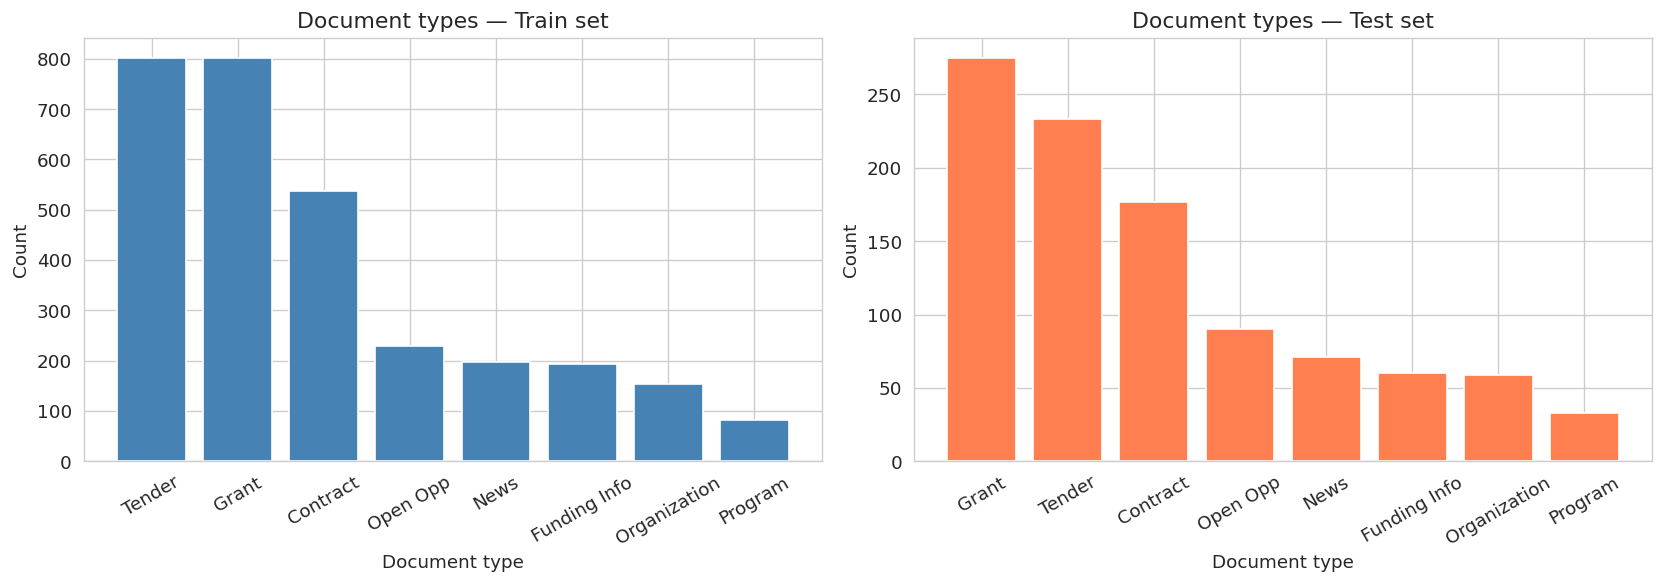

Saved: document_type_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
type_counts_train = train_raw['Type'].value_counts()
axes[0].bar(type_counts_train.index, type_counts_train.values, color='steelblue', edgecolor='white')
axes[0].set_title('Document types — Train set')
axes[0].set_xlabel('Document type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Test
type_counts_test = test_raw['Type'].value_counts()
axes[1].bar(type_counts_test.index, type_counts_test.values, color='coral', edgecolor='white')
axes[1].set_title('Document types — Test set')
axes[1].set_xlabel('Document type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'document_type_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: document_type_distribution.png')

### 3.2 Label Distribution (Class Imbalance Analysis)

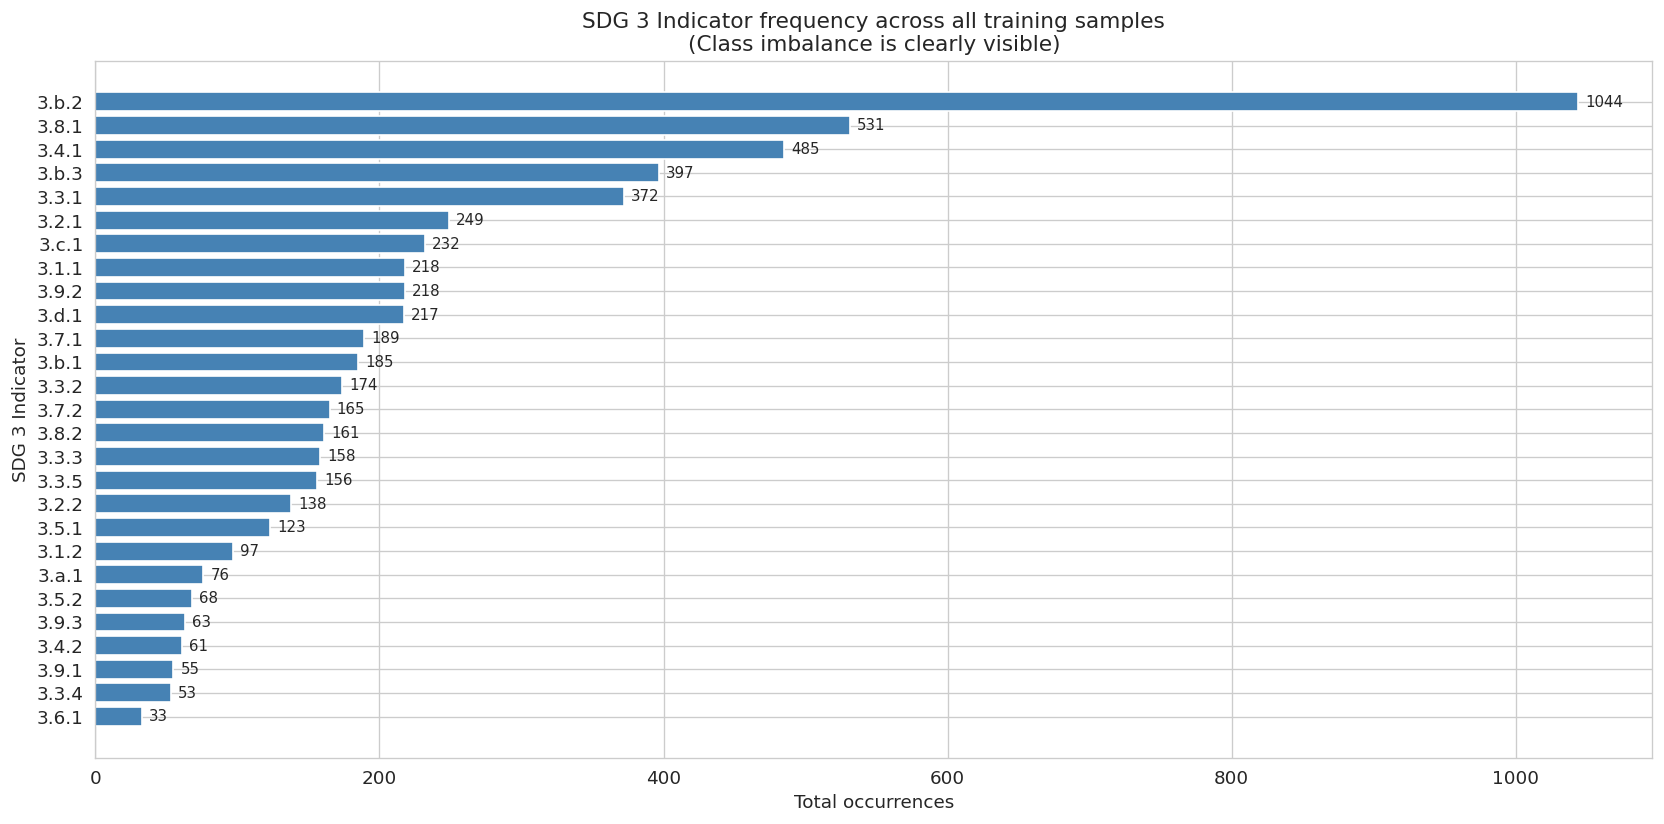

Saved: label_distribution.png

Most frequent: 3.b.2 (1044 samples)
Least frequent: 3.6.1 (33 samples)
Imbalance ratio: 31.6x


In [9]:
# Collect all labels from Label 1 through Label 12
LABEL_COLS = [f'Label {i}' for i in range(1, 13)]

# Count total occurrences of each indicator across all label columns
label_counts = {}
for col in LABEL_COLS:
    for val in train_raw[col].dropna():
        label_counts[val] = label_counts.get(val, 0) + 1

label_counts_series = pd.Series(label_counts).sort_values(ascending=False)

# Shorten label names for display (extract indicator code only)
short_names = [l.split(' - ')[0] for l in label_counts_series.index]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(short_names[::-1], label_counts_series.values[::-1], color='steelblue', edgecolor='white')

# Annotate counts
for bar, val in zip(bars, label_counts_series.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('SDG 3 Indicator frequency across all training samples\n(Class imbalance is clearly visible)', fontsize=13)
ax.set_xlabel('Total occurrences')
ax.set_ylabel('SDG 3 Indicator')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'label_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: label_distribution.png')
print(f'\nMost frequent: {label_counts_series.index[0].split(" - ")[0]} ({label_counts_series.iloc[0]} samples)')
print(f'Least frequent: {label_counts_series.index[-1].split(" - ")[0]} ({label_counts_series.iloc[-1]} samples)')
print(f'Imbalance ratio: {label_counts_series.iloc[0] / label_counts_series.iloc[-1]:.1f}x')

### 3.3 Labels Per Sample Distribution

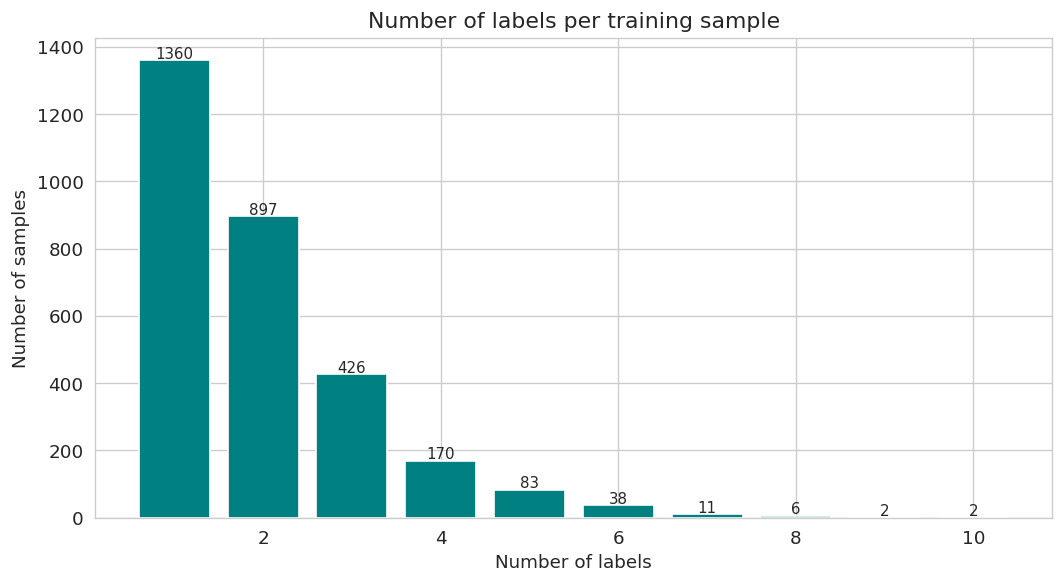

Average labels per sample: 1.98
Max labels in one sample:  10
Samples with 1 label only: 1360


In [10]:
# Count how many labels each training sample has
train_raw['label_count'] = train_raw[LABEL_COLS].notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
vc = train_raw['label_count'].value_counts().sort_index()
ax.bar(vc.index, vc.values, color='teal', edgecolor='white')
ax.set_title('Number of labels per training sample')
ax.set_xlabel('Number of labels')
ax.set_ylabel('Number of samples')

for x, y in zip(vc.index, vc.values):
    ax.text(x, y + 5, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'labels_per_sample.png', bbox_inches='tight')
plt.show()

print(f'Average labels per sample: {train_raw["label_count"].mean():.2f}')
print(f'Max labels in one sample:  {train_raw["label_count"].max()}')
print(f'Samples with 1 label only: {(train_raw["label_count"] == 1).sum()}')

### 3.4 Text Length Analysis

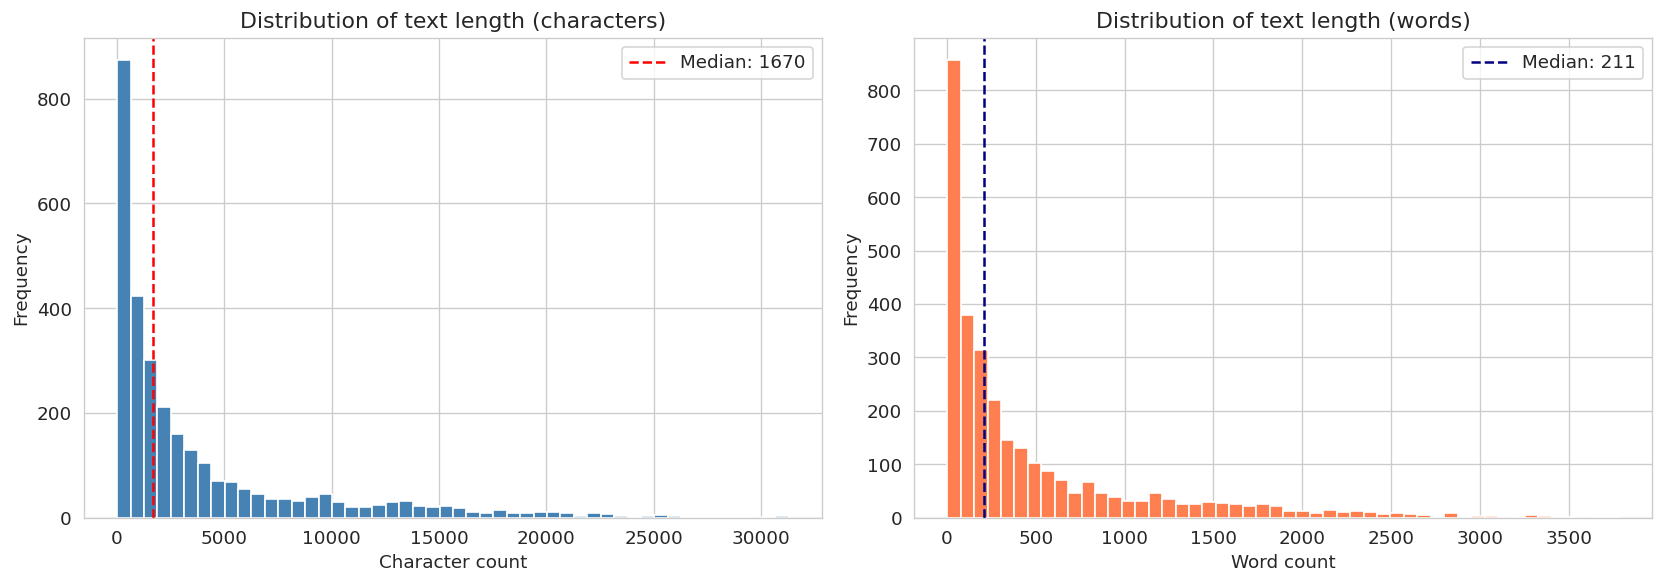

Text length stats (characters):
count     2995.0
mean      3820.6
std       5245.9
min         13.0
25%        131.0
50%       1670.0
75%       4794.0
max      31277.0
Name: text_length, dtype: float64

Word count stats:
count    2995.0
mean      477.7
std       642.0
min         2.0
25%        18.0
50%       211.0
75%       618.5
max      3781.0
Name: word_count, dtype: float64


In [11]:
train_raw['text_length'] = train_raw['Text'].astype(str).apply(len)
train_raw['word_count']  = train_raw['Text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
axes[0].hist(train_raw['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of text length (characters)')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_raw['text_length'].median(), color='red', linestyle='--', label=f'Median: {train_raw["text_length"].median():.0f}')
axes[0].legend()

# Word count
axes[1].hist(train_raw['word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of text length (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(train_raw['word_count'].median(), color='navy', linestyle='--', label=f'Median: {train_raw["word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'text_length_distribution.png', bbox_inches='tight')
plt.show()

print('Text length stats (characters):')
print(train_raw['text_length'].describe().round(1))
print()
print('Word count stats:')
print(train_raw['word_count'].describe().round(1))

### 3.5 Word Cloud & Top Terms Per Label

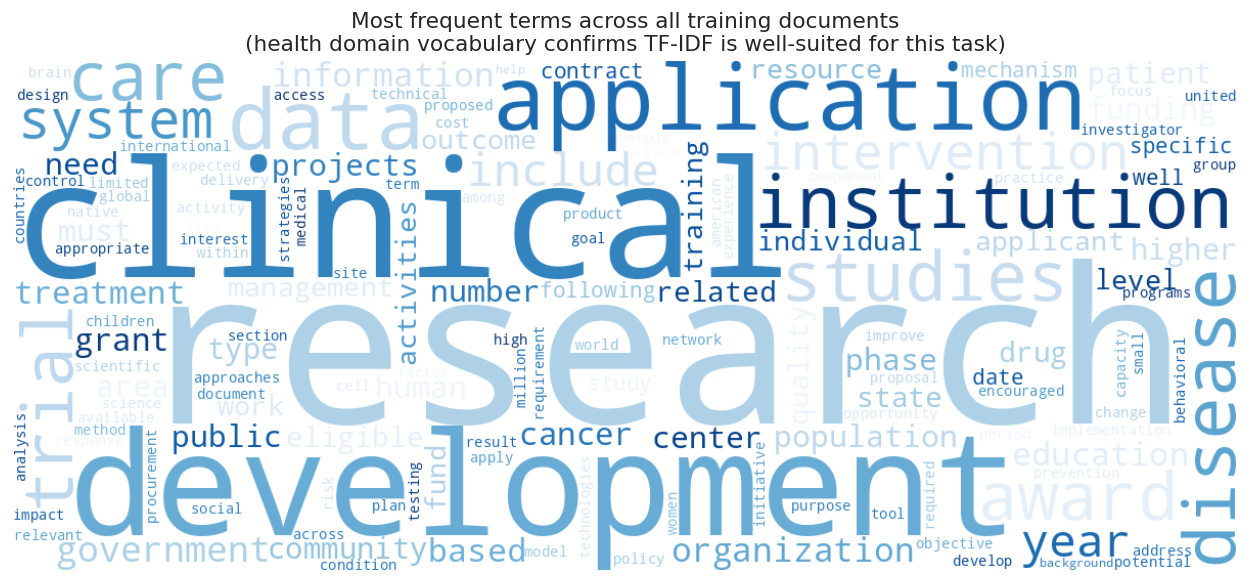

Saved: wordcloud_all.png
INSIGHT: Dominant health terms confirm domain-specific vocabulary —
justifying TF-IDF over generic pre-trained embeddings.


In [12]:
#@title  3.5a Word Cloud - All Training Documents
STOP_WORDS_VIZ = set([
    'the','and','of','to','in','a','is','that','for','on','are','with',
    'this','be','as','at','by','an','it','from','or','was','have','has',
    'will','been','their','which','not','they','also','its','can','all',
    'more','health','project','program','programme','support','provide',
    'new','including','country','national','local','service','services'
])

all_text_raw   = ' '.join(train_raw['Text'].astype(str).values)
all_text_clean = BeautifulSoup(all_text_raw, 'html.parser').get_text()
all_text_clean = re.sub(r'[^a-zA-Z\s]', ' ', all_text_clean).lower()
tokens_viz     = [w for w in all_text_clean.split() if w not in STOP_WORDS_VIZ and len(w) > 3]
all_text_viz   = ' '.join(tokens_viz)

wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    colormap='Blues',
    max_words=150,
    collocations=False
).generate(all_text_viz)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most frequent terms across all training documents\n(health domain vocabulary confirms TF-IDF is well-suited for this task)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'wordcloud_all.png', bbox_inches='tight')
plt.show()
print('Saved: wordcloud_all.png')
print('INSIGHT: Dominant health terms confirm domain-specific vocabulary —')
print('justifying TF-IDF over generic pre-trained embeddings.')

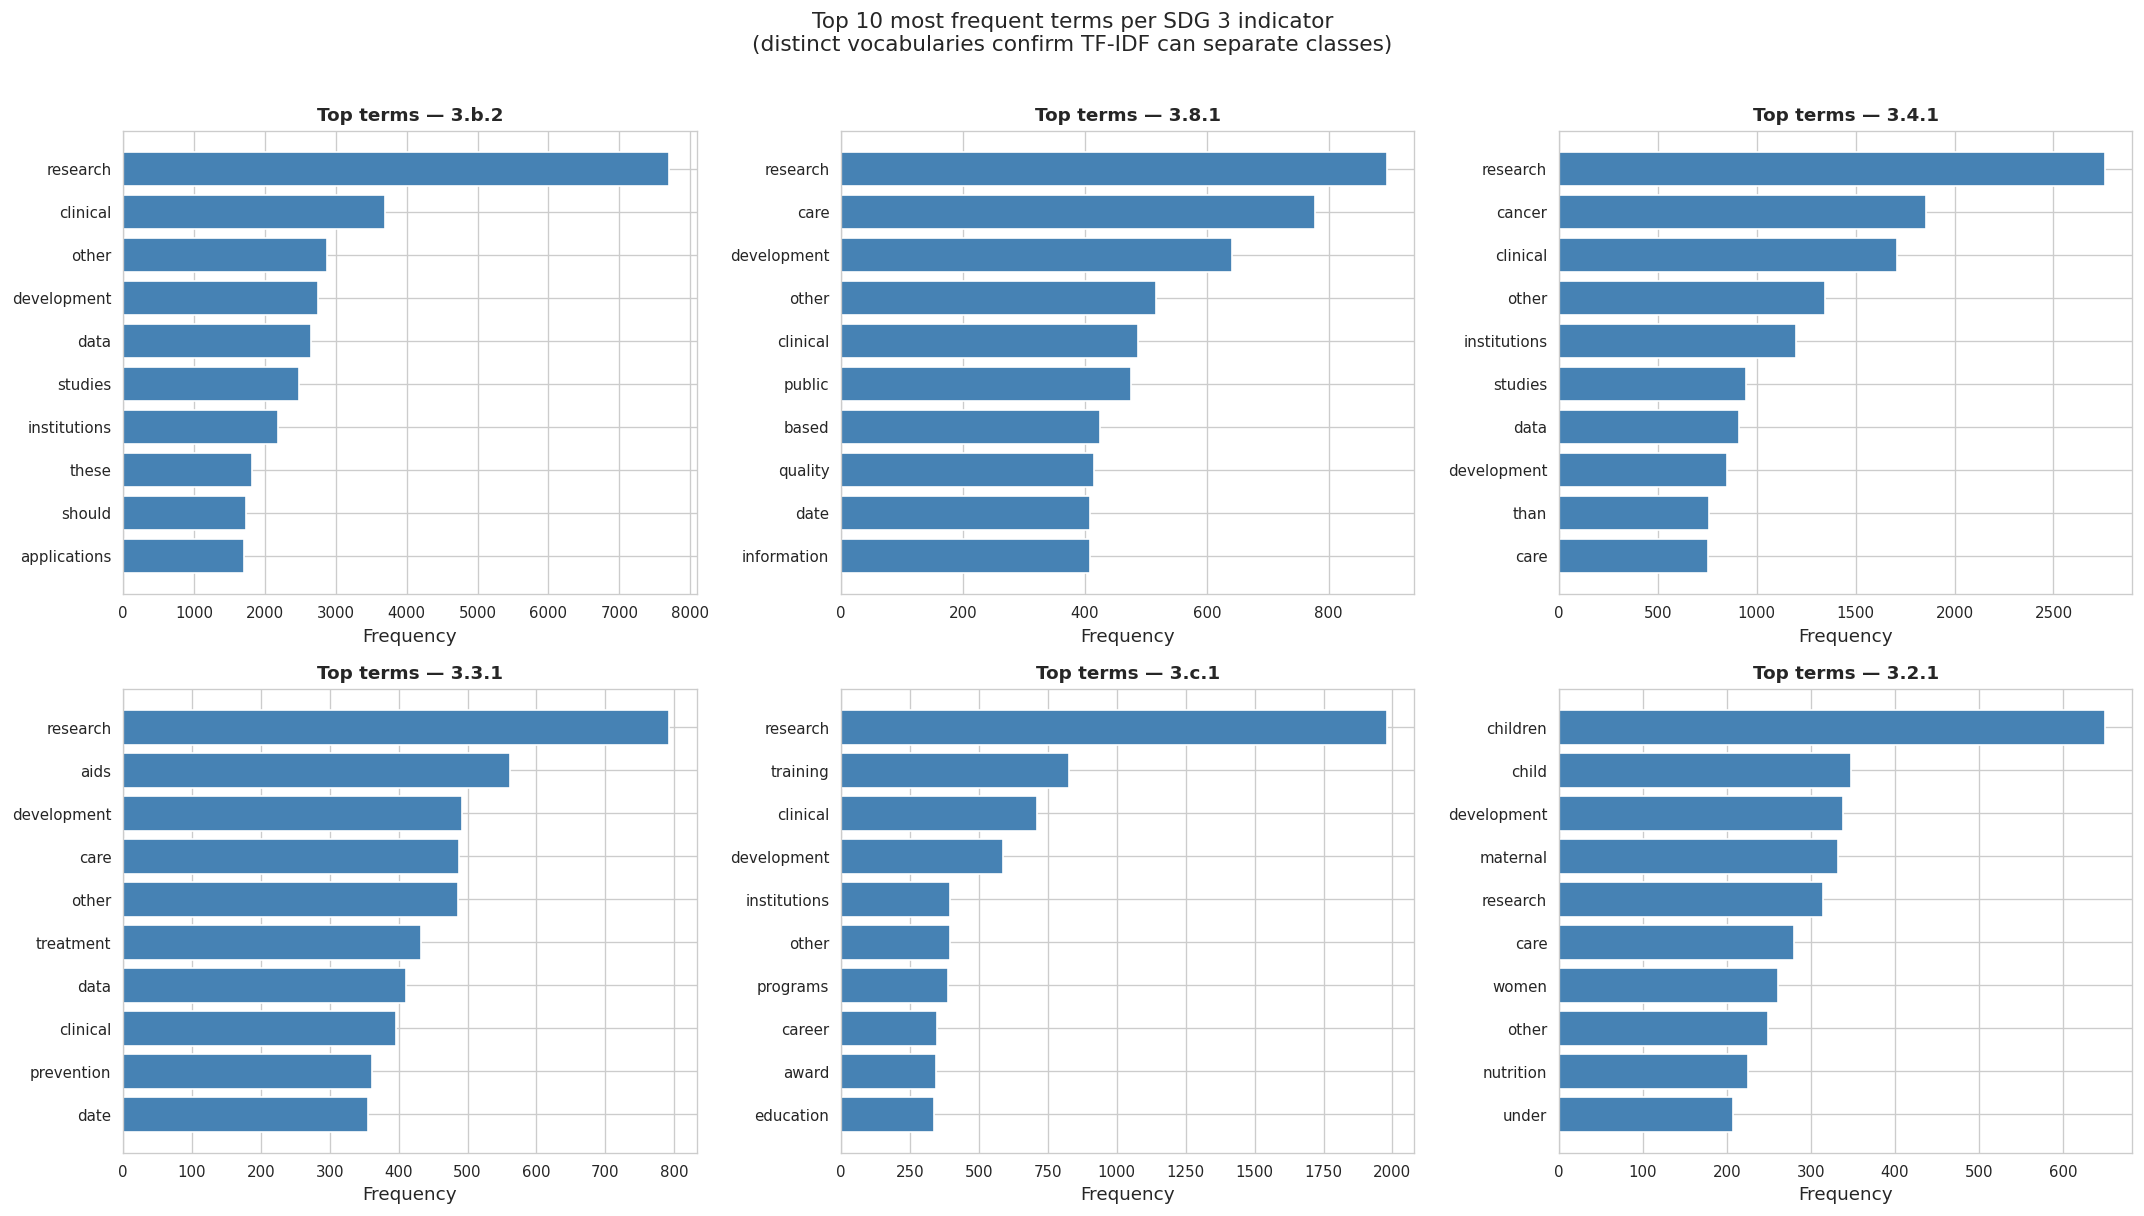

Saved: top_terms_per_label.png


In [14]:
#@title 3.5b Top 10 Terms Per SDG 3 Indicator
# Build label_list if it doesn't exist yet
if 'label_list' not in train_raw.columns:
    def get_labels_tmp(row):
        return [row[col] for col in LABEL_COLS if pd.notna(row[col])]
    train_raw['label_list'] = train_raw.apply(get_labels_tmp, axis=1)

TOP_6_INDICATORS = [
    '3.b.2 - Total net official development assistance to medical research and basic health sector',
    '3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)',
    '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease',
    '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations',
    '3.c.1 - Health worker density and distribution',
    '3.2.1 - Under-5 mortality rate'
]
TOP_6_SHORT = [l.split(' - ')[0] for l in TOP_6_INDICATORS]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, indicator, short in zip(axes, TOP_6_INDICATORS, TOP_6_SHORT):
    mask         = train_raw['label_list'].apply(lambda labels: indicator in labels)
    subset_text  = ' '.join(train_raw.loc[mask, 'Text'].astype(str).values)
    subset_clean = BeautifulSoup(subset_text, 'html.parser').get_text()
    subset_clean = re.sub(r'[^a-zA-Z\s]', ' ', subset_clean).lower()
    tokens       = [w for w in subset_clean.split() if w not in STOP_WORDS_VIZ and len(w) > 3]

    if not tokens:
        ax.set_title(f'{short}\n(no data)')
        ax.axis('off')
        continue

    word_counts = Counter(tokens).most_common(10)
    words  = [w for w, _ in word_counts[::-1]]
    counts = [c for _, c in word_counts[::-1]]

    ax.barh(words, counts, color='steelblue', edgecolor='white')
    ax.set_title(f'Top terms — {short}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.tick_params(labelsize=9)

plt.suptitle('Top 10 most frequent terms per SDG 3 indicator\n(distinct vocabularies confirm TF-IDF can separate classes)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'top_terms_per_label.png', bbox_inches='tight')
plt.show()
print('Saved: top_terms_per_label.png')

### 3.6 Document Type vs Label Analysis

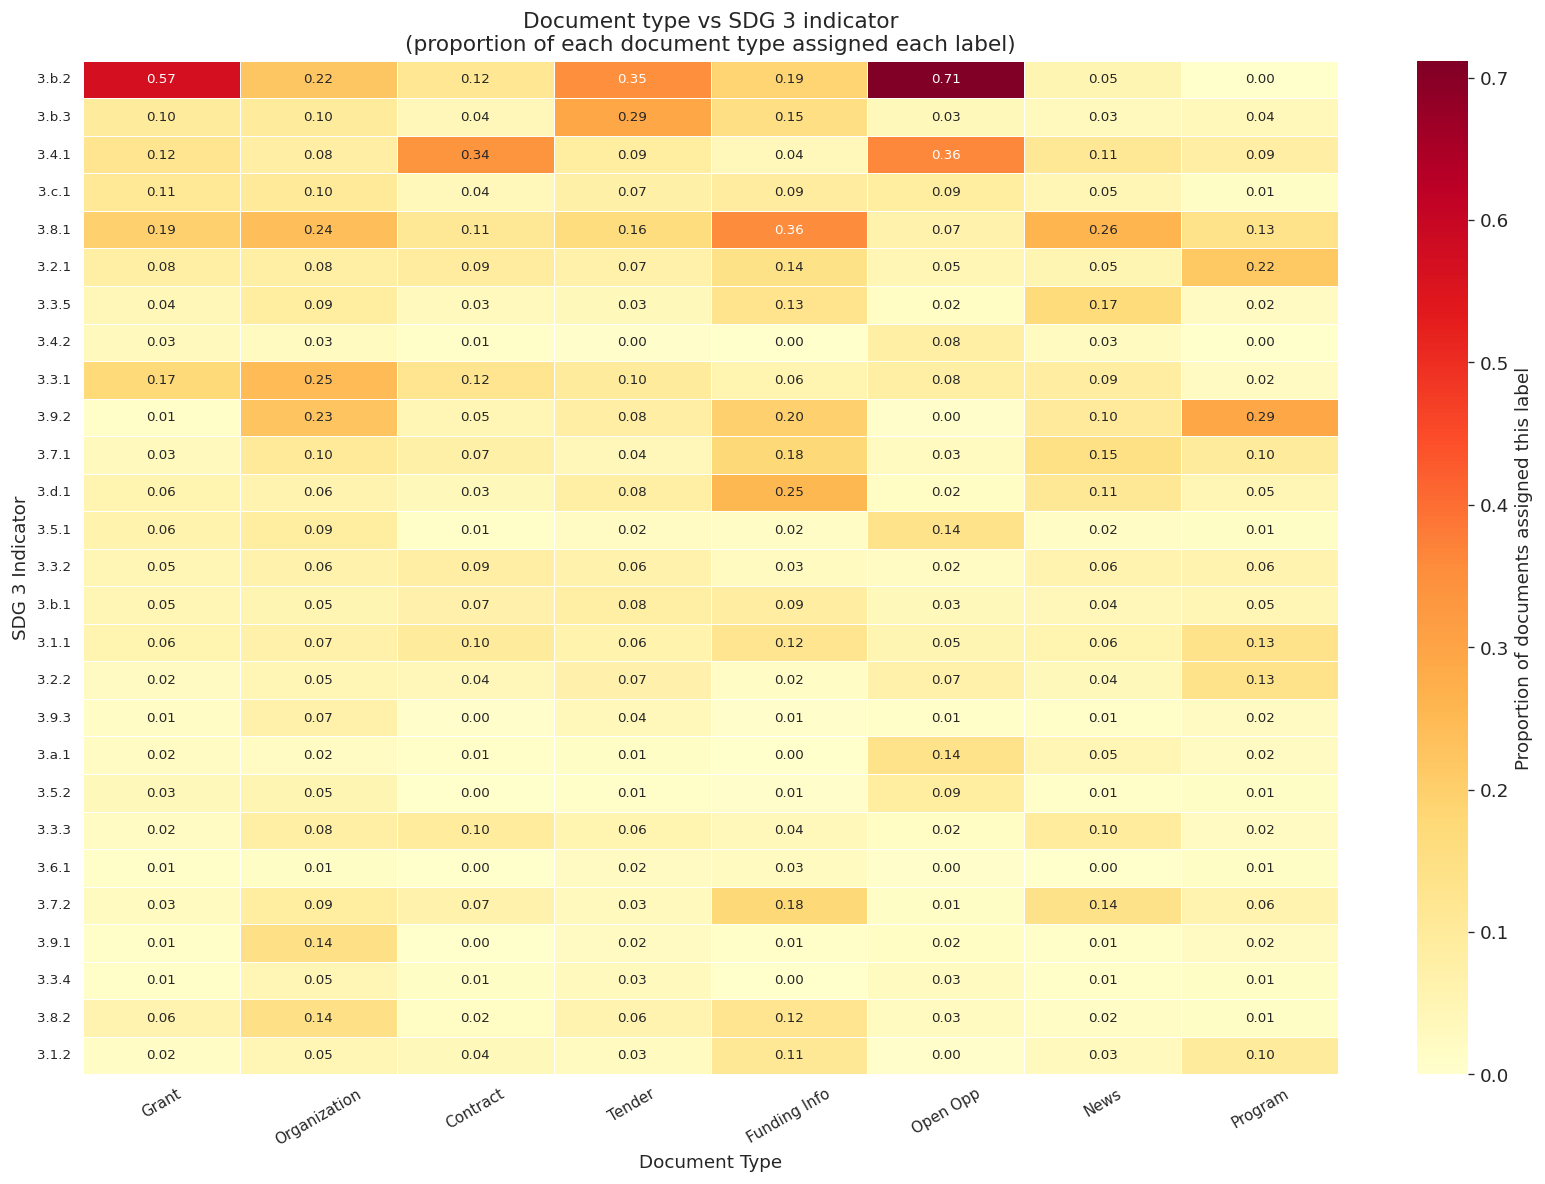

Saved: doctype_vs_label.png
INSIGHT: If certain document types cluster around specific indicators,
document type could be one-hot encoded as an additional feature — future improvement.


In [15]:
#@title 3.6 Document Type vs SDG 3 Indicator Heatmap
type_label_counts = {}

for doc_type in train_raw['Type'].unique():
    subset = train_raw[train_raw['Type'] == doc_type]
    counts = {}
    for col in LABEL_COLS:
        for val in subset[col].dropna():
            short = val.split(' - ')[0]
            counts[short] = counts.get(short, 0) + 1
    type_label_counts[doc_type] = counts

type_label_df = pd.DataFrame(type_label_counts).fillna(0)
type_totals   = train_raw['Type'].value_counts()
for col in type_label_df.columns:
    type_label_df[col] = type_label_df[col] / type_totals.get(col, 1)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    type_label_df, cmap='YlOrRd', ax=ax, linewidths=0.4,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cbar_kws={'label': 'Proportion of documents assigned this label'}
)
ax.set_title('Document type vs SDG 3 indicator\n(proportion of each document type assigned each label)', fontsize=13)
ax.set_xlabel('Document Type')
ax.set_ylabel('SDG 3 Indicator')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'doctype_vs_label.png', bbox_inches='tight')
plt.show()
print('Saved: doctype_vs_label.png')
print('INSIGHT: If certain document types cluster around specific indicators,')
print('document type could be one-hot encoded as an additional feature — future improvement.')

### 3.7 Label Co-occurrence Heatmap

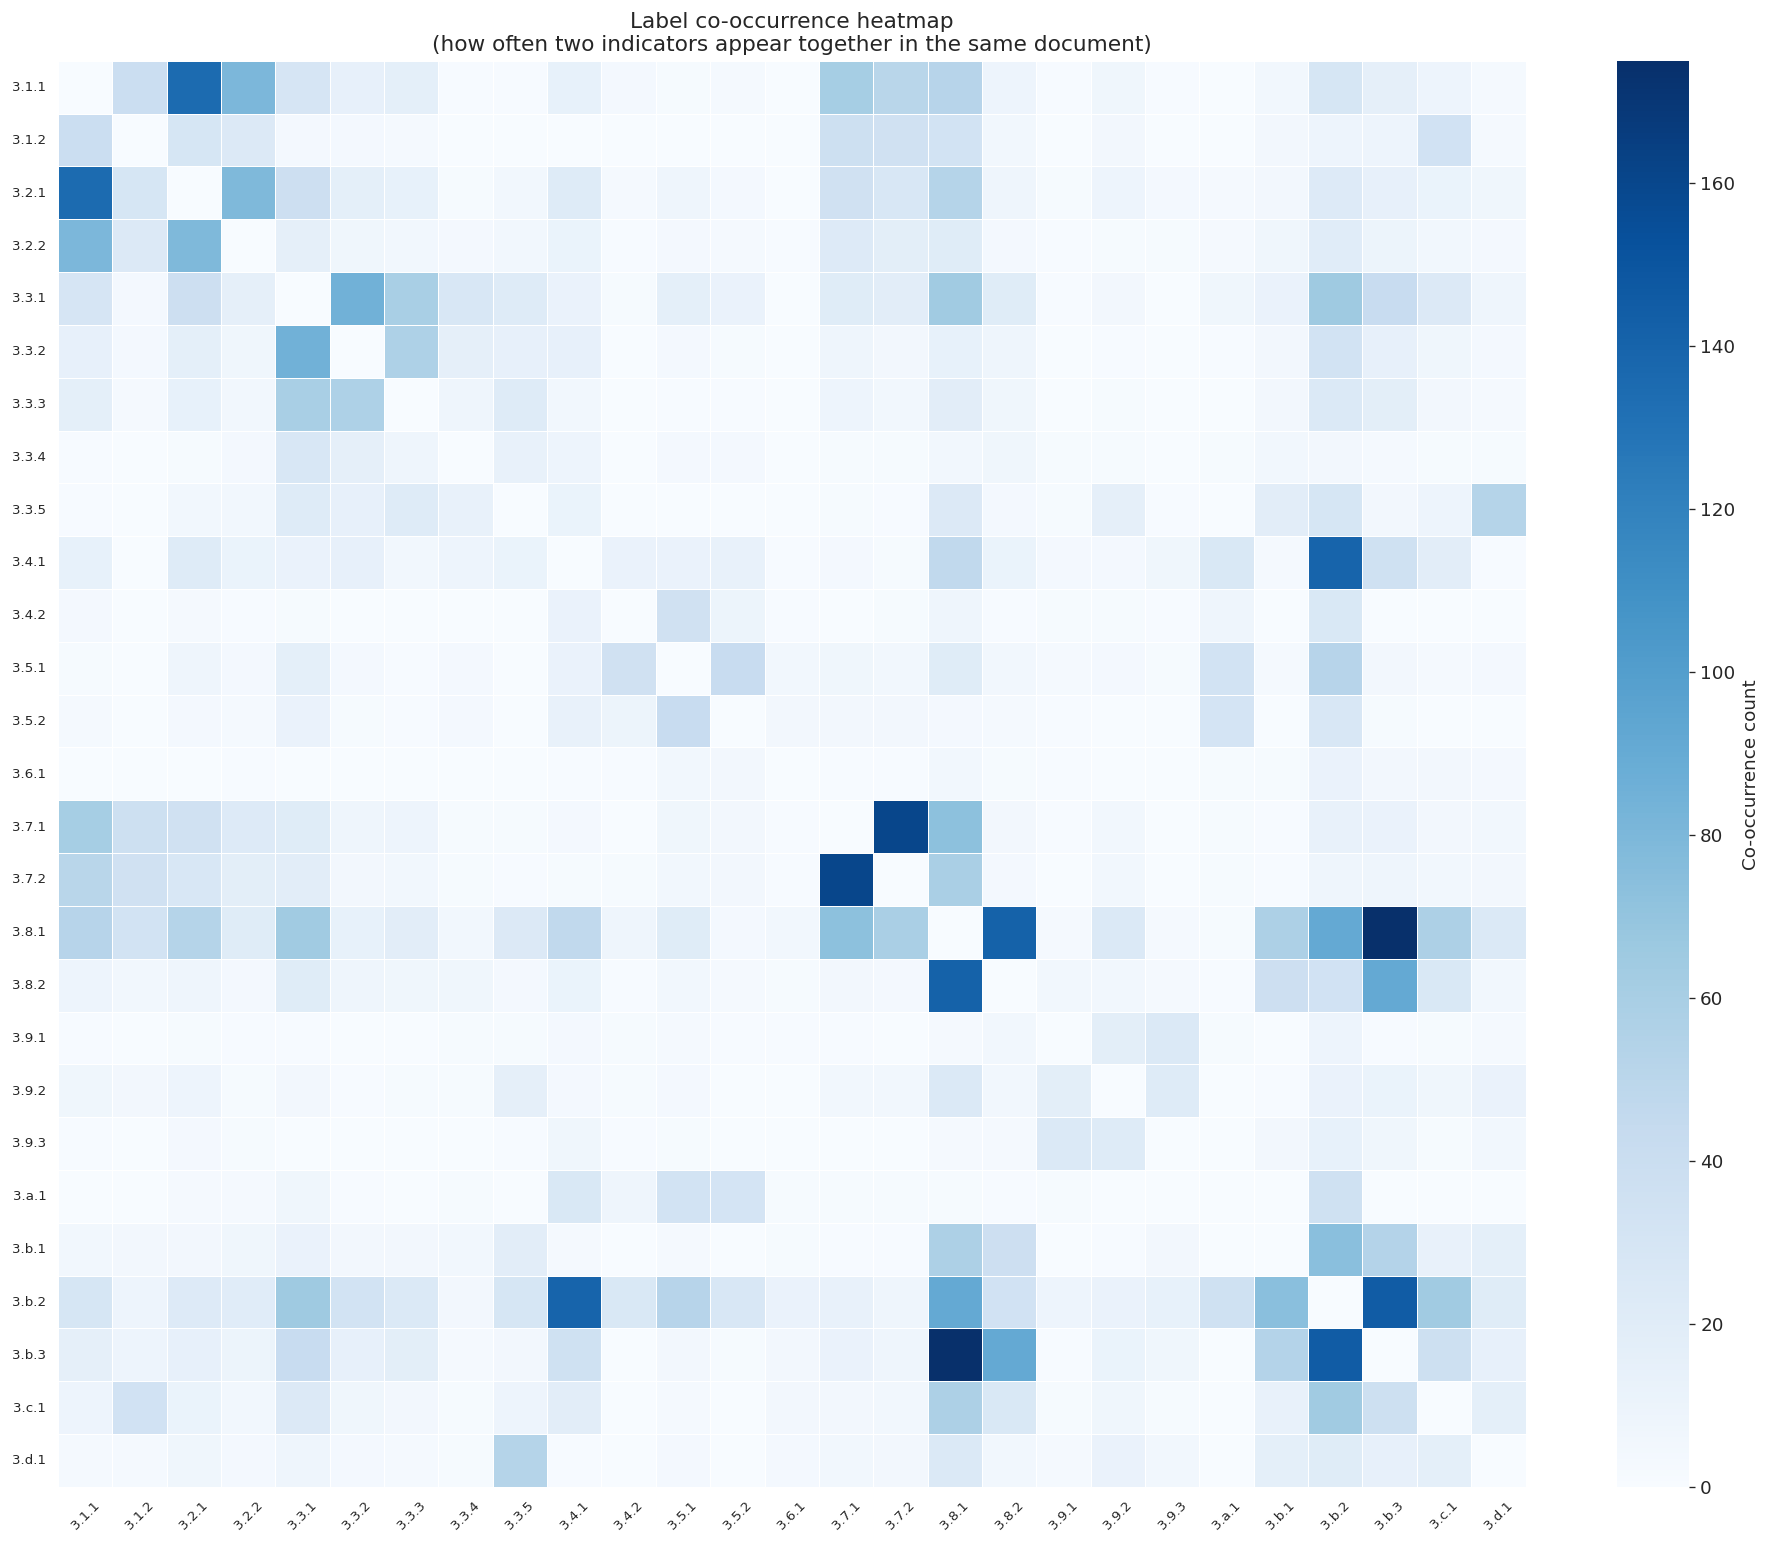

Saved: label_cooccurrence_heatmap.png


In [16]:
# Build binary label matrix first (needed for co-occurrence)
ALL_INDICATORS = sorted([
    '3.1.1 - Maternal mortality ratio',
    '3.1.2 - Proportion of births attended by skilled health personnel',
    '3.2.1 - Under-5 mortality rate',
    '3.2.2 - Neonatal mortality rate',
    '3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations',
    '3.3.2 - Tuberculosis incidence per 100,000 population',
    '3.3.3 - Malaria incidence per 1,000 population',
    '3.3.4 - Hepatitis B incidence per 100,000 population',
    '3.3.5 - Number of people requiring interventions against neglected tropical diseases',
    '3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease',
    '3.4.2 - Suicide mortality rate',
    '3.5.1 - Coverage of treatment interventions (pharmacological, psychosocial and rehabilitation and aftercare services) for substance use disorders',
    '3.5.2 - Harmful use of alcohol, defined according to the national context as alcohol per capita consumption (aged 15 years and older) within a calendar year in litres of pure alcohol',
    '3.6.1 - Death rate due to road traffic injuries',
    '3.7.1 - Proportion of women of reproductive age (aged 15_49 years) who have their need for family planning satisfied with modern methods',
    '3.7.2 - Adolescent birth rate (aged 10_14 years; aged 15_19 years) per 1,000 women in that age group',
    '3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)',
    '3.8.2 - Proportion of population with large household expenditures on health as a share of total household expenditure or income',
    '3.9.1 - Mortality rate attributed to household and ambient air pollution',
    '3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)',
    '3.9.3 - Mortality rate attributed to unintentional poisoning',
    '3.a.1 - Age-standardized prevalence of current tobacco use among persons aged 15 years and older',
    '3.b.1 - Proportion of the target population covered by all vaccines included in their national programme',
    '3.b.2 - Total net official development assistance to medical research and basic health sector',
    '3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis',
    '3.c.1 - Health worker density and distribution',
    '3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness'
])

# Build label lists per row
def get_labels(row):
    return [row[col] for col in LABEL_COLS if pd.notna(row[col])]

train_raw['label_list'] = train_raw.apply(get_labels, axis=1)

# Binarize
mlb = MultiLabelBinarizer(classes=ALL_INDICATORS)
Y_train = mlb.fit_transform(train_raw['label_list'])
label_df = pd.DataFrame(Y_train, columns=ALL_INDICATORS)

# Short codes for display
short_codes = [l.split(' - ')[0] for l in ALL_INDICATORS]
label_df_short = label_df.copy()
label_df_short.columns = short_codes

# Co-occurrence matrix
co_matrix = label_df_short.T.dot(label_df_short)
np.fill_diagonal(co_matrix.values, 0)  # Remove self-co-occurrence

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(co_matrix, cmap='Blues', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Label co-occurrence heatmap\n(how often two indicators appear together in the same document)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'label_cooccurrence_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: label_cooccurrence_heatmap.png')

## 4. Text Preprocessing Pipeline

The raw text contains HTML tags, special characters, numbers, and stop words that add noise without contributing meaning to classification. We build a step-by-step cleaning pipeline and justify each decision.

In [17]:
# Show a raw text example to motivate preprocessing
print('=== RAW TEXT SAMPLE ===')
print(train_raw['Text'].iloc[0][:800])

=== RAW TEXT SAMPLE ===
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not traditionally received significant levels of research funding from the NIH. Created through congressional mandate, the IDeA Program broadens the geographic distribution of NIH funding for competitive biomedical and behavioral research by enhancing the research capabilities of institutions in eligible states. The IDeA Program aims to achieve this goal through two major initiatives: (1) the IDeA Networks of Biomedical Research Excellence (INBRE), and (2) the Centers of Biomedical Research Excellen


In [18]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    """
    Full preprocessing pipeline for a single text document.

    Steps:
    1. Handle null/non-string input
    2. Strip HTML tags — documents contain raw HTML from web sources
    3. Lowercase — reduces vocabulary size without losing meaning
    4. Remove URLs — URLs are not informative for SDG classification
    5. Remove numbers — numerical values do not carry semantic signal
    6. Remove special characters and punctuation
    7. Tokenize
    8. Remove stop words — common words (the, is, at) add noise
    9. Lemmatize — reduces words to base form (running -> run)
    10. Rejoin tokens
    """
    # Step 1: handle nulls
    if not isinstance(text, str):
        return ''

    # Step 2: remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')

    # Step 3: lowercase
    text = text.lower()

    # Step 4: remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 5: remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 6: remove special characters — keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 7: tokenize
    tokens = text.split()

    # Step 8: remove stop words and very short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Step 9: lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 10: rejoin
    return ' '.join(tokens)


# Test on one sample
raw_sample   = train_raw['Text'].iloc[0]
clean_sample = preprocess_text(raw_sample)

print('=== BEFORE preprocessing ===')
print(raw_sample[:400])
print()
print('=== AFTER preprocessing ===')
print(clean_sample[:400])

=== BEFORE preprocessing ===
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not traditionally received significant levels of research funding from the NIH. Created through congress

=== AFTER preprocessing ===
center biomedical research excellence cobre phase iii transitional center funding opportunity description institutional development award idea program endeavor stimulate research institution state traditionally received significant level research funding nih created congressional mandate idea program broadens geographic distribution nih funding competitive biomedical behavioral research enhancing 


In [19]:
# Apply preprocessing to all train and test samples
# This takes 1-2 minutes
print('Preprocessing train set...')
train_raw['clean_text'] = train_raw['Text'].apply(preprocess_text)

print('Preprocessing test set...')
test_raw['clean_text'] = test_raw['Text'].apply(preprocess_text)

print(f'Done. Train: {len(train_raw)} rows | Test: {len(test_raw)} rows')

Preprocessing train set...
Preprocessing test set...
Done. Train: 2995 rows | Test: 998 rows


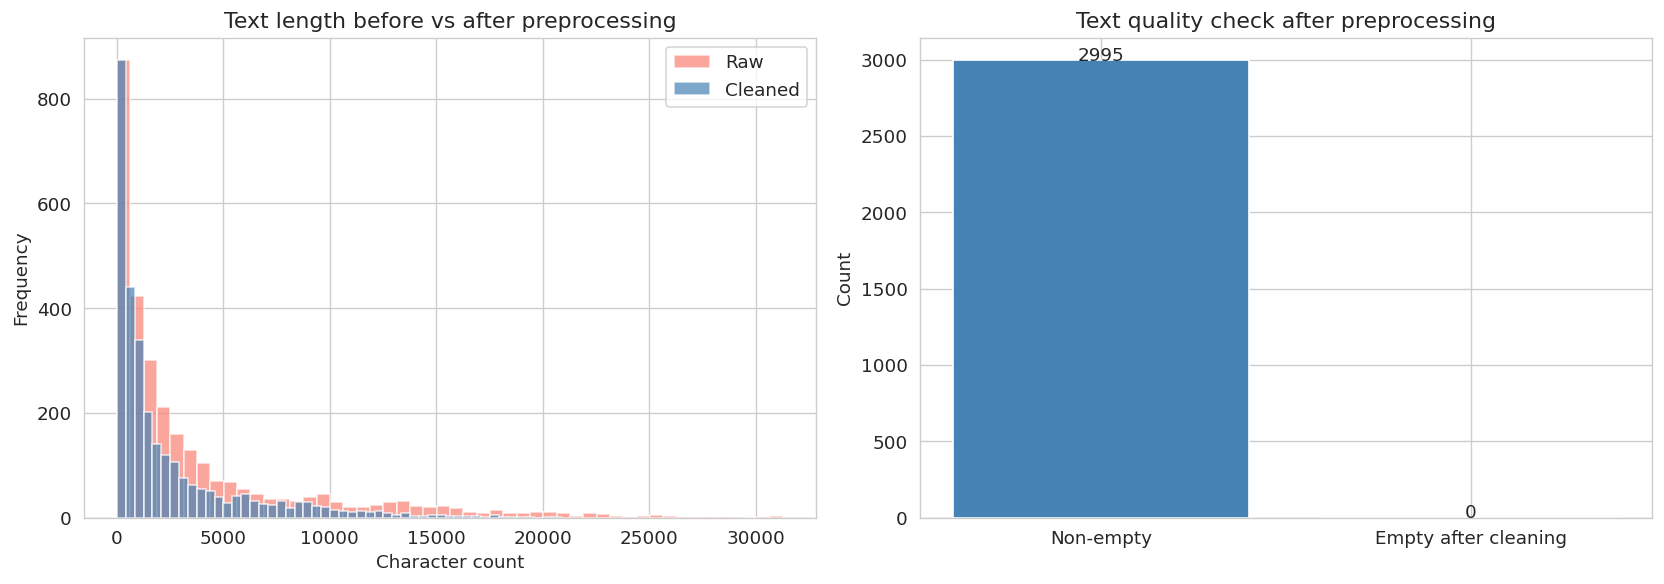

Average text length reduction after preprocessing: 30.6%
Empty texts after cleaning: 0


In [20]:
# Compare text length before and after preprocessing
train_raw['clean_length'] = train_raw['clean_text'].apply(len)
reduction = ((train_raw['text_length'] - train_raw['clean_length']) / train_raw['text_length'] * 100).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_raw['text_length'], bins=50, color='salmon', alpha=0.7, label='Raw')
axes[0].hist(train_raw['clean_length'], bins=50, color='steelblue', alpha=0.7, label='Cleaned')
axes[0].set_title('Text length before vs after preprocessing')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Check for empty texts after preprocessing
empty_count = (train_raw['clean_text'].str.strip() == '').sum()
axes[1].bar(['Non-empty', 'Empty after cleaning'],
            [len(train_raw) - empty_count, empty_count],
            color=['steelblue', 'salmon'], edgecolor='white')
axes[1].set_title('Text quality check after preprocessing')
axes[1].set_ylabel('Count')
for i, v in enumerate([len(train_raw) - empty_count, empty_count]):
    axes[1].text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'preprocessing_effect.png', bbox_inches='tight')
plt.show()

print(f'Average text length reduction after preprocessing: {reduction:.1f}%')
print(f'Empty texts after cleaning: {empty_count}')

## 5. Label Binarization

The dataset stores labels across 12 columns (Label 1 to Label 12). We convert this into a binary matrix of shape (n_samples, 27) where each column represents one SDG 3 indicator and a value of 1 means the sample is associated with that indicator.

In [21]:
# Already built above — confirm shape
print('Binary label matrix shape:', Y_train.shape)
print('Number of unique indicators:', len(ALL_INDICATORS))
print()
print('Label matrix preview (first 5 rows, first 8 columns):')
pd.DataFrame(Y_train[:5], columns=[l.split(' - ')[0] for l in ALL_INDICATORS]).iloc[:, :8]

Binary label matrix shape: (2995, 27)
Number of unique indicators: 27

Label matrix preview (first 5 rows, first 8 columns):


,3.1.1,3.1.2,3.2.1,3.2.2,3.3.1,3.3.2,3.3.3,3.3.4
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0


In [22]:
# Label density — what percentage of labels are positive per sample
label_density = Y_train.mean(axis=1)
print(f'Average label density: {label_density.mean():.4f}')
print(f'(Each sample is positive for {label_density.mean()*100:.2f}% of all 27 labels on average)')

# Per-label positive rate
per_label_rate = pd.Series(Y_train.mean(axis=0), index=[l.split(' - ')[0] for l in ALL_INDICATORS]).sort_values(ascending=False)
print()
print('Per-label positive rate (top 10):')
print(per_label_rate.head(10).round(4))

Average label density: 0.0730
(Each sample is positive for 7.30% of all 27 labels on average)

Per-label positive rate (top 10):
3.b.2    0.3472
3.8.1    0.1766
3.4.1    0.1613
3.b.3    0.1316
3.3.1    0.1239
3.2.1    0.0831
3.c.1    0.0775
3.1.1    0.0728
3.9.2    0.0725
3.d.1    0.0725
dtype: float64


## 6. Save Clean Data for Modelling Notebooks

In [23]:
# Save clean train data with labels
train_clean = pd.DataFrame({
    'Unique ID':   train_raw['Unique ID'],
    'Type':        train_raw['Type'],
    'clean_text':  train_raw['clean_text'],
    'label_list':  train_raw['label_list'].apply(lambda x: '|'.join(x)),
    'label_count': train_raw['label_count']
})

# Append binary columns
label_binary_df = pd.DataFrame(Y_train, columns=ALL_INDICATORS)
train_clean = pd.concat([train_clean.reset_index(drop=True), label_binary_df], axis=1)

# Save clean test data
test_clean = pd.DataFrame({
    'Unique ID':  test_raw['Unique ID'],
    'Type':       test_raw['Type'],
    'clean_text': test_raw['clean_text']
})

train_clean.to_csv(OUTPUT_PATH + 'train_clean.csv', index=False)
test_clean.to_csv(OUTPUT_PATH  + 'test_clean.csv',  index=False)

# Also save the label list for use in other notebooks
import json
with open(OUTPUT_PATH + 'all_indicators.json', 'w') as f:
    json.dump(ALL_INDICATORS, f)

print('Saved:')
print(f'  train_clean.csv   → {train_clean.shape}')
print(f'  test_clean.csv    → {test_clean.shape}')
print(f'  all_indicators.json → {len(ALL_INDICATORS)} labels')

Saved:
  train_clean.csv   → (2995, 32)
  test_clean.csv    → (998, 3)
  all_indicators.json → 27 labels


## 7. EDA Summary

Key findings from this notebook:

In [25]:
print('=== EDA SUMMARY ===')
print(f'Training samples:          {len(train_raw)}')
print(f'Test samples:              {len(test_raw)}')
print(f'Unique SDG 3 indicators:   27')
print(f'Average labels per sample: {train_raw["label_count"].mean():.2f}')
print(f'Max labels per sample:     {train_raw["label_count"].max()}')
print()
print(f'Most common indicator:  3.b.2 ({label_counts_series["3.b.2 - Total net official development assistance to medical research and basic health sector"]} samples)')
print(f'Rarest indicator:       3.7.2 ({label_counts_series["3.7.2 - Adolescent birth rate (aged 10_14 years; aged 15_19 years) per 1,000 women in that age group"]} samples)')
print()
print(f'Class imbalance ratio:     {label_counts_series.iloc[0] / label_counts_series.iloc[-1]:.1f}x')
print(f'Avg text length (chars):   {train_raw["text_length"].mean():.0f}')
print(f'Avg text length (words):   {train_raw["word_count"].mean():.0f}')
print(f'Text reduction after clean: {reduction:.1f}%')
print()
print(f'Key challenge: Severe class imbalance ({label_counts_series.iloc[0] / label_counts_series.iloc[-1]:.1f}x ratio).')
print('This will be addressed in Notebook 2 through class weighting,')
print('per-label threshold tuning, and oversampling experiments.')

=== EDA SUMMARY ===
Training samples:          2995
Test samples:              998
Unique SDG 3 indicators:   27
Average labels per sample: 1.98
Max labels per sample:     10

Most common indicator:  3.b.2 (1044 samples)
Rarest indicator:       3.7.2 (165 samples)

Class imbalance ratio:     31.6x
Avg text length (chars):   3821
Avg text length (words):   478
Text reduction after clean: 30.6%

Key challenge: Severe class imbalance (31.6x ratio).
This will be addressed in Notebook 2 through class weighting,
per-label threshold tuning, and oversampling experiments.
